In [3]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator

from glob import glob
import os

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from matplotlib.patches import Rectangle

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cpu')

In [4]:
collab = False
if collab:
    from google.colab import drive

    drive.mount('/content/drive')
    folder_path = 'drive/MyDrive/ai_data/data'
else:
    folder_path = './data'

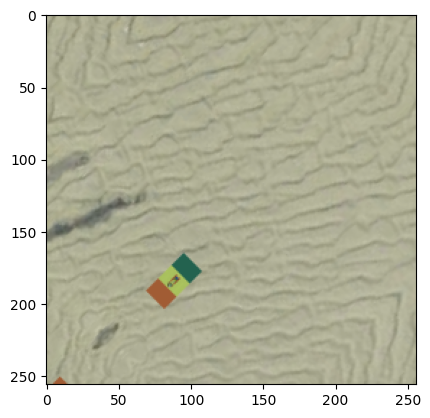

In [5]:
def extract_random_roi(img_shape: np.ndarray, min_percentage: float, max_percentage: float, ratio: float,
                       padding: int = 0) -> (float, float, float, float):
    """
    :param img_shape: shape of the image to take the roi from, shape: HxW 
    :param min_percentage: the minimum size of the roi for both width and height
    :param max_percentage: the maximum size of the roi for both width and height
    :param ratio: width/height ratio
    :return: x, y, w, h of the roi
    """
    assert min_percentage < max_percentage, " min_percentage should be less than max_percentage"
    assert len(img_shape) == 2, "Image should be in shape HxW"
    h_min = img_shape[0] * min_percentage
    h_max = img_shape[0] * max_percentage

    h = np.random.randint(h_min, h_max)
    w = np.int32((1 / ratio) * h)

    y_min, x_min = padding, padding
    y_max = img_shape[0] - h - padding
    x_max = img_shape[1] - w - padding

    y = np.random.randint(y_min, y_max)
    x = np.random.randint(x_min, x_max)

    return int(x), int(y), int(w), int(h)


class FlagOnGround(Dataset):
    def __init__(self, flags_path: str, desert_path: str, apply_augmentations=False):
        self.flags = glob(os.path.join(flags_path, '*.png'))
        self.deserts = glob(os.path.join(desert_path, '*.jpg'))
        self.apply_augmentations = apply_augmentations

        # Basic transformations including resizing, cropping, and normalization
        self.preprocess = transforms.ToTensor()

        # Other augmentations (excluding rotation)
        self.augmentation_pipeline = transforms.Compose([
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))], p=0.5),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        ])

    def __len__(self):
        return len(self.flags)

    def __getitem__(self, bg_idx, flag_idx=-1):
        # Load desert and flag images
        desert_path = self.deserts[bg_idx]
        desert = cv2.imread(desert_path)
        desert = cv2.cvtColor(desert, cv2.COLOR_BGR2RGB)

        flag_path = np.random.choice(self.flags) if flag_idx < 0 else self.flags[flag_idx]
        flag = cv2.imread(flag_path)
        flag = cv2.cvtColor(flag, cv2.COLOR_BGR2RGB)

        # Generate random ROI for flag placement
        flag_x_min, flag_y_min, flag_w, flag_h = extract_random_roi(desert.shape[:2], 0.05, 0.15, 2, 256 - 224)
        flag_y_max = flag_y_min + flag_h
        flag_x_max = flag_x_min + flag_w

        # Resize and place flag on desert image
        flag = cv2.resize(flag, (flag_w, flag_h))
        desert[flag_y_min: flag_y_max, flag_x_min: flag_x_max] = flag

        # Convert to PIL for other augmentations if enabled
        if self.apply_augmentations:
            # Convert desert back to array for OpenCV rotation
            desert = np.array(self.augmentation_pipeline(Image.fromarray(desert)))

            # Define rotation matrix for the whole image
            angle = np.random.uniform(-180, 180)
            h, w = desert.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)

            # Apply rotation with border replication
            desert = cv2.warpAffine(desert, M, (w, h), borderMode=cv2.BORDER_REFLECT)

        # Final preprocessing
        desert = self.preprocess(Image.fromarray(desert))

        # Adjust bounding box if rotation is applied (optional step)
        return desert.to(device), torch.tensor([flag_x_min, flag_y_min, flag_x_max, flag_y_max], device=device)


dataset = FlagOnGround(os.path.join(folder_path, 'flags/'), os.path.join(folder_path, 'desert/'), True)
img, rect = dataset[0]

plt.imshow(img.cpu().detach().permute(1, 2, 0))

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)


In [6]:
anchor_generator = AnchorGenerator(
    sizes=(2, 4, 8),
    aspect_ratios=(0.5, 1.0, 1.5)
)

model = models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT").to(device)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)

for param in model.backbone.parameters():
    param.requires_grad = False

# model.load_state_dict(torch.load(os.path.join(folder_path, 'checkpoints/1_resnet50_no_aug.pt'), weights_only=True))

<All keys matched successfully>

In [410]:
model.train()

# Set up the optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model = model.to(device)
    for images, targets in dataloader:
        targets_dict = [
            {
                'boxes': t.unsqueeze(0),
                'labels': torch.tensor([1])
            } for t in targets
        ]
        loss_dict = model(images, targets_dict)
        losses = sum(loss for loss in loss_dict.values())

        print(losses)
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}, Loss: {losses.item()}")
    model.to(torch.device('cpu'))
    torch.save(model.state_dict(), os.path.join(folder_path, 'checkpoints/1_resnet50_no_aug.pt'))

tensor(0.1131, grad_fn=<AddBackward0>)
tensor(0.0722, grad_fn=<AddBackward0>)


KeyboardInterrupt: 

In [67]:
model.eval()


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

tensor(0.1434, grad_fn=<SelectBackward0>)
114.30254364013672 153.42054748535156 121.83634185791016 169.84295654296875


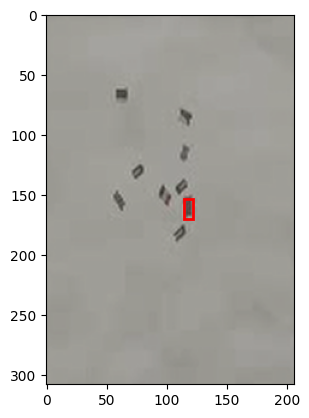

In [84]:
img = cv2.cvtColor(cv2.imread('./data/dummy/img.png'), cv2.COLOR_BGR2RGB)
img_t = transforms.ToTensor()(img)
# img = img_t = dataset[20][0]
result = model(img_t.unsqueeze(0))[0]
# img_t = transforms.ToTensor()(img)
boxes, scores = result['boxes'], result['scores']

if len(scores) > 0: print(scores[0])
if len(boxes) > 0:
    x1, y1, x2, y2 = boxes[0]
    x1 = x1.item()
    y1 = y1.item()
    x2 = x2.item()
    y2 = y2.item()

    ax = plt.gca()
    print(x1, y1, x2, y2)
    rect = Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
else:
    print('no shit')

plt.imshow(img_t.permute(1, 2, 0))

In [85]:
# Load the video and analyze with jumping frames
to_tensor = transforms.ToTensor()

input_video_path = './data/test/rzaz_vid.mp4'
output_video_path = './data/test/output_rzaz.mp4'
cap = cv2.VideoCapture(input_video_path)

# Set video writer for output
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_fps = cap.get(cv2.CAP_PROP_FPS)
frame_width, frame_height = 800, 800  # Desired frame size

# Slow down factor (e.g., 2 will double the length, 3 will triple it)
slow_down_factor = 20
out = cv2.VideoWriter(output_video_path, fourcc, out_fps, (frame_width, frame_height))

# Get total frame count for progress tracking
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Skip interval in seconds
skip_interval = 1
skip_frames = int(skip_interval * out_fps)

while cap.isOpened():
    current_frame = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
    ret, frame = cap.read()
    if not ret:
        break

    # Resize the frame to 500x500
    resized_frame = cv2.resize(frame, (frame_width, frame_height))

    # Convert frame to a PIL image and apply the transformations
    pil_image = Image.fromarray(cv2.cvtColor(resized_frame, cv2.COLOR_BGR2RGB))
    image_tensor = to_tensor(pil_image).unsqueeze(0)

    # Get predictions from the model
    with torch.no_grad():
        predictions = model(image_tensor)[0]

    # Extract boxes and scores from predictions
    boxes, scores = predictions['boxes'], predictions['scores']

    # Draw the boxes on the frame for visual confirmation
    for i, box in enumerate(boxes):
        print(scores[i])
        if scores[i] > 0:  # Confidence threshold
            x1, y1, x2, y2 = box.int().tolist()
            cv2.rectangle(resized_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Write the frame to the output video multiple times to slow it down
    for _ in range(slow_down_factor):
        out.write(resized_frame)

    # Calculate and print progress percentage
    progress_percentage = (current_frame / total_frames) * 100
    print(f'Progress: {progress_percentage:.2f}%')

    # Skip frames
    cap.set(cv2.CAP_PROP_POS_FRAMES, current_frame + skip_frames)

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()

Progress: 0.00%
Progress: 1.49%
tensor(0.0724)
tensor(0.0687)
Progress: 2.97%
tensor(0.0526)
Progress: 4.46%
Progress: 5.95%
Progress: 7.44%
Progress: 8.92%
Progress: 10.41%
Progress: 11.90%
Progress: 13.39%
Progress: 14.87%
Progress: 16.36%
Progress: 17.85%
Progress: 19.34%
Progress: 20.82%
Progress: 22.31%
Progress: 23.80%
Progress: 25.29%
Progress: 26.77%
Progress: 28.26%
Progress: 29.75%
Progress: 31.23%
Progress: 32.72%
Progress: 34.21%
Progress: 35.70%
Progress: 37.18%
Progress: 38.67%
Progress: 40.16%
Progress: 41.65%
Progress: 43.13%
Progress: 44.62%
Progress: 46.11%
Progress: 47.60%
Progress: 49.08%
tensor(0.3810)
tensor(0.2817)
tensor(0.1194)
tensor(0.1080)
tensor(0.0592)
tensor(0.0541)
Progress: 50.57%
tensor(0.5105)
tensor(0.3091)
tensor(0.2218)
tensor(0.1866)
tensor(0.1493)
tensor(0.0944)
tensor(0.0904)
tensor(0.0818)
tensor(0.0705)
tensor(0.0627)
tensor(0.0580)
tensor(0.0573)
tensor(0.0511)
Progress: 52.06%
tensor(0.5150)
tensor(0.3160)
tensor(0.2276)
tensor(0.1870)
tenso

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'
